# Evaluate VPR models from similarity CSV files

This notebook compares the best variant of each model selected by the corresponding `*_thesis_figures.ipynb` notebook. It uses the place labels in `datasets/dataset-2/labels/` and does not rerun any model.

A retrieved database image is considered correct when its label matches the query label. Around each label transition, both neighboring labels are accepted for an adjustable number of frames in both traversals. Strict recall is reported alongside transition-tolerant recall. The reported metrics are:

- **Recall@K (VPR success rate):** percentage of queries with at least one correct image in the top K. This is the primary VPR metric.
- **Precision@K:** average fraction of the top K images that have the correct label.
- **MRR@K:** average reciprocal rank of the first correct result, or zero when none occurs in the top K.
- **mAP@K:** mean average precision within the first K results.

Similarity files are read one row at a time. Only the top `max(TOP_K_VALUES)` indices are retained, so memory usage stays small.

In [10]:
from pathlib import Path
import csv
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

DATABASE_LABELS_CSV = PROJECT_ROOT / 'datasets/dataset-2/labels/frames-IMG_3609.csv'
QUERY_LABELS_CSV = PROJECT_ROOT / 'datasets/dataset-2/labels/frames-IMG_3610.csv'
# Best variants selected by the matching *_thesis_figures.ipynb notebooks.
MODEL_FILES = {
    'AnyLoc': PROJECT_ROOT / 'outputs/_anyloc_similarity.csv',
    'CosPlace (ResNet50, 2048-D)': PROJECT_ROOT / 'outputs/cosplace/_cosplace_resnet50_2048_similarity.csv',
    'MixVPR': PROJECT_ROOT / 'outputs/_mixvpr_similarity.csv',
    'NetVLAD (ResNet101-conv4, Pitts30k)': PROJECT_ROOT / 'outputs/netvlad/_netvlad_resnet101conv4_pitts30k_similarity.csv',
}
missing_files = [path for path in MODEL_FILES.values() if not path.is_file()]
if missing_files:
    raise FileNotFoundError('Missing thesis-selected similarity files: ' + ', '.join(str(path) for path in missing_files))
SIMILARITY_FILES = list(MODEL_FILES.values())
MODEL_NAME_BY_PATH = {path.resolve(): name for name, path in MODEL_FILES.items()}

# Change this list to evaluate different retrieval depths.
TOP_K_VALUES = [1, 5, 10]
PROGRESS_EVERY = 500
NORMALIZE_LABEL_CASE = True
TRANSITION_TOLERANCE_FRAMES = 20  # Set to 0 for exact-label evaluation only.

# Metric tables are saved here after evaluation.
SUMMARY_CSV = PROJECT_ROOT / 'outputs/vpr_metrics.csv'
PER_LABEL_CSV = PROJECT_ROOT / 'outputs/vpr_metrics_by_label.csv'
CONFUSION_CSV = PROJECT_ROOT / 'outputs/vpr_label_confusions.csv'
TEXT_REPORT = PROJECT_ROOT / 'outputs/vpr_best_models_report.txt'
FIGURE_DIR = PROJECT_ROOT / 'outputs/thesis_figures/model_comparison'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
CONFUSION_TEXT_DIR = PROJECT_ROOT / 'outputs/vpr_confusions_text'
CONFUSION_TEXT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Using {len(SIMILARITY_FILES)} thesis-selected model variants:')
for path in SIMILARITY_FILES:
    print(f'  {MODEL_NAME_BY_PATH[path.resolve()]}: {path.relative_to(PROJECT_ROOT)} ({path.stat().st_size / 1024**2:.1f} MiB)')

Using 4 thesis-selected model variants:
  AnyLoc: outputs/_anyloc_similarity.csv (722.6 MiB)
  CosPlace (ResNet50, 2048-D): outputs/cosplace/_cosplace_resnet50_2048_similarity.csv (748.0 MiB)
  MixVPR: outputs/_mixvpr_similarity.csv (753.9 MiB)
  NetVLAD (ResNet101-conv4, Pitts30k): outputs/netvlad/_netvlad_resnet101conv4_pitts30k_similarity.csv (733.5 MiB)


## Load and validate the ground-truth labels

The similarity columns are named `database_0`, `database_1`, and so on. The retrieval pipeline creates these columns from database image paths sorted by filename, so this notebook reconstructs the same ordering from the database label CSV.

In [11]:
def normalize_label(value):
    value = value.strip()
    return value.casefold() if NORMALIZE_LABEL_CASE else value


def load_labels(csv_path):
    labels = []
    with csv_path.open(newline='', encoding='utf-8') as handle:
        reader = csv.DictReader(handle)
        required = {'image_path', 'frame_index', 'label'}
        if reader.fieldnames is None or not required.issubset(reader.fieldnames):
            raise ValueError(f'{csv_path} must contain columns: {sorted(required)}')
        for row_number, row in enumerate(reader, start=2):
            image_name = Path(row['image_path']).name
            label = normalize_label(row['label'])
            if not image_name or not label:
                raise ValueError(f'Empty image path or label at {csv_path}:{row_number}')
            labels.append((image_name, int(row['frame_index']), label))

    names = [item[0] for item in labels]
    duplicate_names = [name for name, count in Counter(names).items() if count > 1]
    if duplicate_names:
        raise ValueError(f'Duplicate image names in {csv_path}: {duplicate_names[:5]}')
    return labels


def transition_acceptable_labels(rows, radius):
    if radius < 0:
        raise ValueError('TRANSITION_TOLERANCE_FRAMES cannot be negative.')
    ordered = sorted(rows, key=lambda item: item[1])
    acceptable = [{label} for _, _, label in ordered]
    if radius:
        for transition_index in range(1, len(ordered)):
            left_label = ordered[transition_index - 1][2]
            right_label = ordered[transition_index][2]
            if left_label == right_label:
                continue
            start = max(0, transition_index - radius)
            end = min(len(ordered), transition_index + radius)
            for index in range(start, end):
                acceptable[index].update((left_label, right_label))
    return {row[0]: frozenset(labels) for row, labels in zip(ordered, acceptable)}


database_label_rows = load_labels(DATABASE_LABELS_CSV)
database_rows = sorted(database_label_rows, key=lambda item: item[0])
query_rows = load_labels(QUERY_LABELS_CSV)
database_labels = np.asarray([item[2] for item in database_rows], dtype=object)
query_label_by_name = {item[0]: item[2] for item in query_rows}
database_acceptable_by_name = transition_acceptable_labels(database_label_rows, TRANSITION_TOLERANCE_FRAMES)
query_acceptable_by_name = transition_acceptable_labels(query_rows, TRANSITION_TOLERANCE_FRAMES)
database_acceptable_labels = [database_acceptable_by_name[item[0]] for item in database_rows]
database_relevant_counts = Counter(database_labels.tolist())

print(f'Database labels: {len(database_rows):,} images, {len(database_relevant_counts)} places')
print(f'Query labels:    {len(query_rows):,} images, {len(set(query_label_by_name.values()))} places')
query_only_labels = sorted(set(query_label_by_name.values()) - set(database_relevant_counts))
if query_only_labels:
    print(f'Warning: query labels with no database match: {query_only_labels}')
else:
    print('Every query label has at least one possible database match.')

Database labels: 9,318 images, 23 places
Query labels:    4,284 images, 19 places
Every query label has at least one possible database match.


## Stream each similarity file and compute the metrics

This is the time-consuming evaluation cell. It parses every similarity value, but processes only one query row at a time. Progress is printed every `PROGRESS_EVERY` queries.

In [12]:
def model_name_from_path(path):
    resolved = path.resolve()
    if resolved not in MODEL_NAME_BY_PATH:
        raise KeyError(f'No display name configured for {path}')
    return MODEL_NAME_BY_PATH[resolved]


def top_indices(scores, top_k):
    top_k = min(top_k, scores.size)
    if top_k == scores.size:
        return np.argsort(-scores)
    candidates = np.argpartition(scores, -top_k)[-top_k:]
    return candidates[np.argsort(-scores[candidates])]


def query_metrics(relevance, total_relevant, k):
    relevant_at_k = relevance[:k]
    ranks = np.flatnonzero(relevant_at_k) + 1
    recall = float(ranks.size > 0)
    precision = float(relevant_at_k.mean())
    reciprocal_rank = 1.0 / ranks[0] if ranks.size else 0.0
    if ranks.size:
        precisions_at_relevant = np.arange(1, ranks.size + 1) / ranks
        average_precision = float(precisions_at_relevant.sum() / min(total_relevant, k))
    else:
        average_precision = 0.0
    return recall, precision, reciprocal_rank, average_precision


def evaluate_similarity_file(csv_path, top_k_values):
    model = model_name_from_path(csv_path)
    top_k_values = sorted(set(int(k) for k in top_k_values))
    if not top_k_values or top_k_values[0] < 1:
        raise ValueError('TOP_K_VALUES must contain positive integers.')
    max_k = min(max(top_k_values), len(database_labels))

    totals = {k: np.zeros(4, dtype=np.float64) for k in top_k_values}
    per_label_totals = defaultdict(lambda: {k: np.zeros(4, dtype=np.float64) for k in top_k_values})
    per_label_queries = Counter()
    confusion_counts = Counter()
    evaluated = 0
    missing_query_label = 0
    no_database_match = 0

    print(f'\nEvaluating {model}: {csv_path.name}', flush=True)
    with csv_path.open(newline='', encoding='utf-8') as handle:
        reader = csv.reader(handle)
        header = next(reader, None)
        if header is None or header[:2] != ['query_index', 'query_path']:
            raise ValueError(f'Unexpected similarity CSV header in {csv_path}')
        database_columns = header[2:]
        if len(database_columns) != len(database_labels):
            raise ValueError(
                f'{csv_path.name} contains {len(database_columns):,} database columns, '
                f'but the database label CSV contains {len(database_labels):,} images.'
            )
        expected_columns = [f'database_{index}' for index in range(len(database_labels))]
        if database_columns != expected_columns:
            raise ValueError(f'Database columns are not sequential in {csv_path}')

        for row_number, row in enumerate(reader, start=2):
            if len(row) != len(header):
                raise ValueError(
                    f'Malformed row {row_number} in {csv_path.name}: '
                    f'expected {len(header)} columns, found {len(row)}.'
                )
            query_name = Path(row[1]).name
            query_label = query_label_by_name.get(query_name)
            if query_label is None:
                missing_query_label += 1
                continue
            total_relevant = database_relevant_counts.get(query_label, 0)
            if total_relevant == 0:
                no_database_match += 1
                continue

            scores = np.fromiter((float(value) for value in row[2:]), dtype=np.float32, count=len(database_labels))
            if not np.all(np.isfinite(scores)):
                scores = np.nan_to_num(scores, nan=-np.inf, posinf=np.finfo(np.float32).max, neginf=-np.inf)
            indices = top_indices(scores, max_k)
            predicted_label = str(database_labels[indices[0]])
            confusion_counts[(query_label, predicted_label)] += 1
            relevance = database_labels[indices] == query_label

            for k in top_k_values:
                values = query_metrics(relevance, total_relevant, min(k, max_k))
                totals[k] += values
                per_label_totals[query_label][k] += values
            evaluated += 1
            per_label_queries[query_label] += 1
            if evaluated % PROGRESS_EVERY == 0:
                print(f'  processed {evaluated:,} queries', flush=True)

    if evaluated == 0:
        raise ValueError(f'No labeled queries could be evaluated in {csv_path}')

    summary_rows = []
    for k in top_k_values:
        mean_values = totals[k] / evaluated
        summary_rows.append({
            'model': model,
            'similarity_file': csv_path.name,
            'evaluated_queries': evaluated,
            'skipped_missing_query_label': missing_query_label,
            'skipped_no_database_match': no_database_match,
            'k': k,
            'recall_at_k': mean_values[0],
            'precision_at_k': mean_values[1],
            'mrr_at_k': mean_values[2],
            'map_at_k': mean_values[3],
        })

    label_rows = []
    for label in sorted(per_label_queries):
        count = per_label_queries[label]
        for k in top_k_values:
            mean_values = per_label_totals[label][k] / count
            label_rows.append({
                'model': model, 'label': label, 'query_count': count, 'k': k,
                'recall_at_k': mean_values[0], 'precision_at_k': mean_values[1],
                'mrr_at_k': mean_values[2], 'map_at_k': mean_values[3],
            })
    confusion_rows = []
    errors_by_true_label = Counter()
    for (true_label, predicted_label), count in confusion_counts.items():
        if predicted_label != true_label:
            errors_by_true_label[true_label] += count
    for (true_label, predicted_label), count in sorted(confusion_counts.items()):
        query_count = per_label_queries[true_label]
        error_count = errors_by_true_label[true_label]
        is_correct = predicted_label == true_label
        confusion_rows.append({
            'model': model,
            'true_label': true_label,
            'predicted_label': predicted_label,
            'is_correct': is_correct,
            'count': count,
            'query_count': query_count,
            'error_count': error_count,
            'rate_among_all_queries': count / query_count,
            'rate_among_errors': 0.0 if is_correct or error_count == 0 else count / error_count,
        })

    print(f'  finished {evaluated:,} evaluated queries', flush=True)
    return summary_rows, label_rows, confusion_rows


def write_dict_rows(path, rows):
    if not rows:
        return
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open('w', newline='', encoding='utf-8') as handle:
        writer = csv.DictWriter(handle, fieldnames=list(rows[0]))
        writer.writeheader()
        writer.writerows(rows)

In [13]:
# Reload labels here so rerunning this cell never uses labels cached before
# the CSV files were edited.
database_rows = sorted(load_labels(DATABASE_LABELS_CSV), key=lambda item: item[0])
query_rows = load_labels(QUERY_LABELS_CSV)
database_labels = np.asarray([item[2] for item in database_rows], dtype=object)
query_label_by_name = {item[0]: item[2] for item in query_rows}
database_relevant_counts = Counter(database_labels.tolist())

all_summary_rows = []
all_label_rows = []
all_confusion_rows = []
for similarity_file in SIMILARITY_FILES:
    summary_rows, label_rows, confusion_rows = evaluate_similarity_file(similarity_file, TOP_K_VALUES)
    all_summary_rows.extend(summary_rows)
    all_label_rows.extend(label_rows)
    all_confusion_rows.extend(confusion_rows)

write_dict_rows(SUMMARY_CSV, all_summary_rows)
write_dict_rows(PER_LABEL_CSV, all_label_rows)
write_dict_rows(CONFUSION_CSV, all_confusion_rows)
print(f'\nSaved overall metrics to {SUMMARY_CSV}')
print(f'Saved per-label metrics to {PER_LABEL_CSV}')
print(f'Saved top-1 label confusions to {CONFUSION_CSV}')


Evaluating AnyLoc: _anyloc_similarity.csv
  processed 500 queries
  processed 1,000 queries
  processed 1,500 queries
  processed 2,000 queries
  processed 2,500 queries
  processed 3,000 queries
  processed 3,500 queries
  processed 4,000 queries
  finished 4,284 evaluated queries

Evaluating CosPlace (ResNet50, 2048-D): _cosplace_resnet50_2048_similarity.csv
  processed 500 queries
  processed 1,000 queries
  processed 1,500 queries
  processed 2,000 queries
  processed 2,500 queries
  processed 3,000 queries
  processed 3,500 queries
  processed 4,000 queries
  finished 4,284 evaluated queries

Evaluating MixVPR: _mixvpr_similarity.csv
  processed 500 queries
  processed 1,000 queries
  processed 1,500 queries
  processed 2,000 queries
  processed 2,500 queries
  processed 3,000 queries
  processed 3,500 queries
  processed 4,000 queries
  finished 4,284 evaluated queries

Evaluating NetVLAD (ResNet101-conv4, Pitts30k): _netvlad_resnet101conv4_pitts30k_similarity.csv
  processed 50

## Overall comparison

In [14]:
def markdown_table(rows, columns, percent_columns=()):
    header = '| ' + ' | '.join(columns) + ' |'
    separator = '| ' + ' | '.join(['---'] * len(columns)) + ' |'
    body = []
    for row in rows:
        values = []
        for column in columns:
            value = row[column]
            if column in percent_columns:
                values.append(f'{100 * value:.2f}%')
            elif isinstance(value, float):
                values.append(f'{value:.4f}')
            else:
                values.append(str(value))
        body.append('| ' + ' | '.join(values) + ' |')
    return '\n'.join([header, separator, *body])


summary_columns = ['model', 'k', 'recall_at_k', 'precision_at_k', 'mrr_at_k', 'map_at_k', 'evaluated_queries']
summary_text = markdown_table(
    all_summary_rows, summary_columns,
    percent_columns={'recall_at_k', 'precision_at_k', 'mrr_at_k', 'map_at_k'},
)
report_lines = [
    'BEST VPR MODEL VARIANTS — DATASET-2',
    'Selection criterion: highest strict Recall@1 in each *_thesis_figures.ipynb notebook.',
    '',
]
for model in sorted({row['model'] for row in all_summary_rows}):
    rows = sorted((row for row in all_summary_rows if row['model'] == model), key=lambda row: row['k'])
    report_lines.append(model)
    report_lines.append('  ' + ' | '.join(f"Recall@{row['k']}={100 * row['recall_at_k']:.2f}%" for row in rows))
report_lines.extend(['', 'FULL METRICS', summary_text])
report_text = '\n'.join(report_lines)
TEXT_REPORT.write_text(report_text + '\n', encoding='utf-8')
print(report_text)
print(f'\nSaved AI-friendly text report to {TEXT_REPORT}')

BEST VPR MODEL VARIANTS — DATASET-2
Selection criterion: highest strict Recall@1 in each *_thesis_figures.ipynb notebook.

AnyLoc
  Recall@1=81.07% | Recall@5=84.94% | Recall@10=86.62%
CosPlace (ResNet50, 2048-D)
  Recall@1=74.00% | Recall@5=79.81% | Recall@10=82.19%
MixVPR
  Recall@1=77.52% | Recall@5=82.07% | Recall@10=85.39%
NetVLAD (ResNet101-conv4, Pitts30k)
  Recall@1=78.55% | Recall@5=83.26% | Recall@10=85.95%

FULL METRICS
| model | k | recall_at_k | precision_at_k | mrr_at_k | map_at_k | evaluated_queries |
| --- | --- | --- | --- | --- | --- | --- |
| AnyLoc | 1 | 81.07% | 81.07% | 81.07% | 81.07% | 4284 |
| AnyLoc | 5 | 84.94% | 80.43% | 82.46% | 79.34% | 4284 |
| AnyLoc | 10 | 86.62% | 79.79% | 82.69% | 78.07% | 4284 |
| CosPlace (ResNet50, 2048-D) | 1 | 74.00% | 74.00% | 74.00% | 74.00% | 4284 |
| CosPlace (ResNet50, 2048-D) | 5 | 79.81% | 73.37% | 76.05% | 71.77% | 4284 |
| CosPlace (ResNet50, 2048-D) | 10 | 82.19% | 72.02% | 76.36% | 69.61% | 4284 |
| MixVPR | 1 | 77.52%

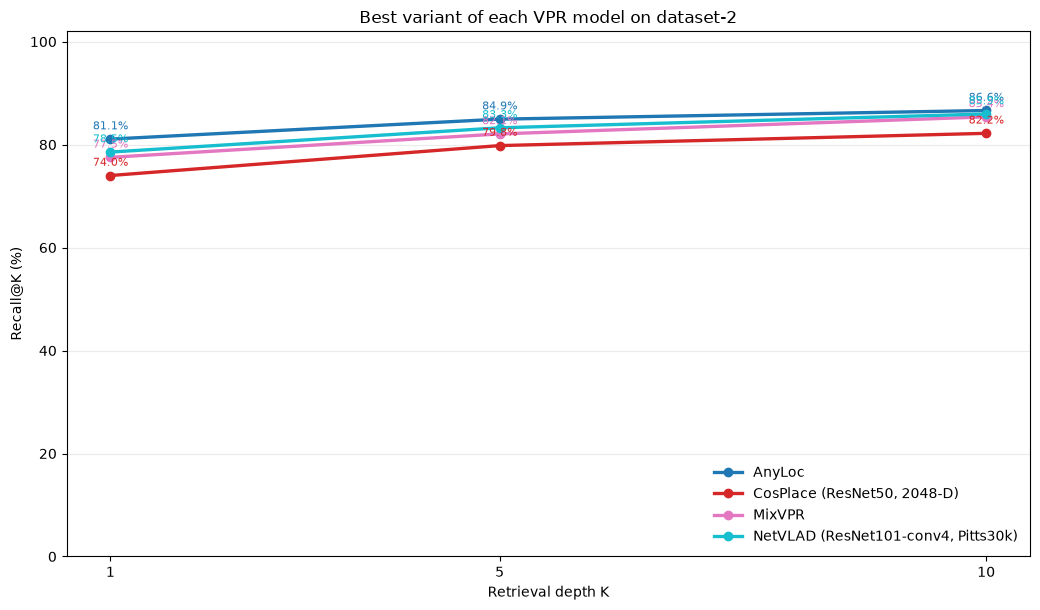

In [15]:
models = sorted({row['model'] for row in all_summary_rows})
figure, axis = plt.subplots(figsize=(10.5, 6.2))
colors = plt.cm.tab10(np.linspace(0, 1, len(models)))
for color, model in zip(colors, models):
    rows = sorted((row for row in all_summary_rows if row['model'] == model), key=lambda row: row['k'])
    x = [row['k'] for row in rows]
    y = [100 * row['recall_at_k'] for row in rows]
    axis.plot(x, y, marker='o', linewidth=2.4, markersize=6, label=model, color=color)
    for k, value in zip(x, y):
        axis.annotate(f'{value:.1f}%', (k, value), xytext=(0, 7), textcoords='offset points', ha='center', fontsize=8, color=color)
axis.set(title='Best variant of each VPR model on dataset-2', xlabel='Retrieval depth K', ylabel='Recall@K (%)', xticks=TOP_K_VALUES, ylim=(0, 102))
axis.grid(axis='y', alpha=.25)
axis.legend(frameon=False, loc='lower right')
figure.tight_layout()
figure.savefig(FIGURE_DIR / 'best_models_recall_at_k.pdf', bbox_inches='tight')
figure.savefig(FIGURE_DIR / 'best_models_recall_at_k.png', bbox_inches='tight', dpi=300)
plt.show()

## Per-place diagnosis

Change `SELECTED_K` to inspect another retrieval depth. The table is sorted from the lowest to highest Recall@K, which highlights the most difficult places.

In [16]:
SELECTED_K = 5
if SELECTED_K not in TOP_K_VALUES:
    raise ValueError(f'SELECTED_K must be one of {TOP_K_VALUES}')

per_label_selected = sorted(
    (row for row in all_label_rows if row['k'] == SELECTED_K),
    key=lambda row: (row['recall_at_k'], row['model'], row['label']),
)
per_label_columns = ['model', 'label', 'query_count', 'recall_at_k', 'precision_at_k', 'mrr_at_k', 'map_at_k']
display(Markdown(markdown_table(
    per_label_selected, per_label_columns,
    percent_columns={'recall_at_k', 'precision_at_k', 'mrr_at_k', 'map_at_k'},
)))

| model | label | query_count | recall_at_k | precision_at_k | mrr_at_k | map_at_k |
| --- | --- | --- | --- | --- | --- | --- |
| CosPlace (ResNet50, 2048-D) | 1 lobby | 72 | 0.00% | 0.00% | 0.00% | 0.00% |
| MixVPR | 1 b stairs | 50 | 0.00% | 0.00% | 0.00% | 0.00% |
| MixVPR | 1 lobby | 72 | 0.00% | 0.00% | 0.00% | 0.00% |
| NetVLAD (ResNet101-conv4, Pitts30k) | 1 b stairs | 50 | 0.00% | 0.00% | 0.00% | 0.00% |
| CosPlace (ResNet50, 2048-D) | 1 b stairs | 50 | 2.00% | 0.40% | 0.40% | 0.08% |
| NetVLAD (ResNet101-conv4, Pitts30k) | 1 lobby | 72 | 2.78% | 0.56% | 0.93% | 0.19% |
| AnyLoc | 1 b stairs | 50 | 12.00% | 5.20% | 5.07% | 2.75% |
| NetVLAD (ResNet101-conv4, Pitts30k) | 1 stairs | 140 | 16.43% | 15.43% | 16.43% | 15.38% |
| AnyLoc | 1 stairs | 140 | 17.14% | 13.86% | 16.31% | 13.50% |
| CosPlace (ResNet50, 2048-D) | 1 stairs | 140 | 20.00% | 17.29% | 18.48% | 16.92% |
| MixVPR | 1 stairs | 140 | 22.14% | 18.43% | 22.14% | 18.34% |
| AnyLoc | 1 lobby | 72 | 27.78% | 10.00% | 14.21% | 5.67% |
| CosPlace (ResNet50, 2048-D) | 0 b stairs | 231 | 35.06% | 28.83% | 31.03% | 27.27% |
| AnyLoc | 0 b stairs | 231 | 36.80% | 31.17% | 33.63% | 30.05% |
| NetVLAD (ResNet101-conv4, Pitts30k) | 0 b stairs | 231 | 37.23% | 28.57% | 31.25% | 26.48% |
| MixVPR | 0 b stairs | 231 | 37.66% | 35.76% | 37.32% | 35.56% |
| CosPlace (ResNet50, 2048-D) | 1 corridor | 490 | 58.16% | 48.49% | 50.34% | 45.08% |
| MixVPR | 1 corridor | 490 | 59.39% | 41.84% | 47.78% | 37.74% |
| AnyLoc | 2 lobby | 234 | 67.95% | 58.89% | 65.13% | 57.57% |
| CosPlace (ResNet50, 2048-D) | 2 lobby | 234 | 68.80% | 62.05% | 66.11% | 60.69% |
| CosPlace (ResNet50, 2048-D) | 3 b stairs | 68 | 73.53% | 60.59% | 69.90% | 59.15% |
| MixVPR | 3 b stairs | 68 | 75.00% | 73.53% | 74.02% | 73.33% |
| NetVLAD (ResNet101-conv4, Pitts30k) | 3 b stairs | 68 | 75.00% | 71.76% | 73.28% | 71.03% |
| NetVLAD (ResNet101-conv4, Pitts30k) | 1 corridor | 490 | 75.10% | 66.90% | 70.14% | 64.79% |
| NetVLAD (ResNet101-conv4, Pitts30k) | 2 lobby | 234 | 75.21% | 69.49% | 72.33% | 68.12% |
| MixVPR | 2 lobby | 234 | 76.07% | 69.49% | 72.36% | 67.86% |
| AnyLoc | 1 corridor | 490 | 78.98% | 69.80% | 72.52% | 67.13% |
| CosPlace (ResNet50, 2048-D) | -1 b stairs | 229 | 80.79% | 65.59% | 69.53% | 62.22% |
| AnyLoc | 3 b stairs | 68 | 80.88% | 80.00% | 79.78% | 79.60% |
| CosPlace (ResNet50, 2048-D) | 3 lobby | 99 | 82.83% | 69.29% | 78.65% | 66.09% |
| AnyLoc | 3 lobby | 99 | 84.85% | 82.42% | 84.18% | 82.14% |
| MixVPR | 3 lobby | 99 | 85.86% | 78.38% | 79.80% | 75.06% |
| NetVLAD (ResNet101-conv4, Pitts30k) | 3 elevator area | 192 | 86.98% | 79.27% | 83.05% | 77.18% |
| CosPlace (ResNet50, 2048-D) | 3 elevator area | 192 | 88.54% | 78.54% | 82.49% | 76.32% |
| MixVPR | -1 b stairs | 229 | 89.96% | 84.28% | 86.75% | 82.79% |
| MixVPR | 3 elevator area | 192 | 90.10% | 79.27% | 84.11% | 75.63% |
| NetVLAD (ResNet101-conv4, Pitts30k) | 2 elevator area | 385 | 90.13% | 78.49% | 83.16% | 75.72% |
| NetVLAD (ResNet101-conv4, Pitts30k) | 0 stairs | 230 | 90.43% | 85.83% | 87.39% | 84.65% |
| AnyLoc | 3 elevator area | 192 | 90.62% | 86.15% | 88.30% | 84.83% |
| NetVLAD (ResNet101-conv4, Pitts30k) | -1 b stairs | 229 | 91.70% | 80.96% | 84.93% | 77.87% |
| CosPlace (ResNet50, 2048-D) | 0 lobby | 152 | 92.76% | 85.79% | 90.37% | 84.42% |
| NetVLAD (ResNet101-conv4, Pitts30k) | 3 lobby | 99 | 92.93% | 79.80% | 90.40% | 78.00% |
| MixVPR | 0 lobby | 152 | 93.42% | 90.66% | 92.16% | 89.75% |
| NetVLAD (ResNet101-conv4, Pitts30k) | -1 lobby | 111 | 93.69% | 91.53% | 92.57% | 91.22% |
| AnyLoc | -1 b stairs | 229 | 93.89% | 82.71% | 88.92% | 80.19% |
| AnyLoc | 2 corridor | 150 | 94.00% | 90.27% | 91.29% | 88.99% |
| CosPlace (ResNet50, 2048-D) | 2 elevator area | 385 | 94.03% | 85.82% | 90.40% | 84.03% |
| CosPlace (ResNet50, 2048-D) | 2 corridor | 150 | 94.67% | 88.67% | 91.19% | 86.75% |
| CosPlace (ResNet50, 2048-D) | 0 stairs | 230 | 94.78% | 87.30% | 90.47% | 85.46% |
| CosPlace (ResNet50, 2048-D) | 0 corridor | 181 | 95.03% | 89.39% | 90.51% | 87.59% |
| CosPlace (ResNet50, 2048-D) | 3 corridor | 645 | 95.04% | 91.84% | 93.52% | 91.25% |
| AnyLoc | 0 stairs | 230 | 95.65% | 91.91% | 92.99% | 90.79% |
| MixVPR | 2 corridor | 150 | 96.00% | 94.53% | 95.33% | 94.04% |
| NetVLAD (ResNet101-conv4, Pitts30k) | 2 corridor | 150 | 96.00% | 90.80% | 92.99% | 89.55% |
| MixVPR | 0 stairs | 230 | 96.09% | 93.65% | 94.39% | 93.01% |
| MixVPR | -1 lobby | 111 | 96.40% | 96.04% | 96.40% | 95.96% |
| MixVPR | 3 corridor | 645 | 96.43% | 91.19% | 93.19% | 89.80% |
| CosPlace (ResNet50, 2048-D) | -1 lobby | 111 | 97.30% | 89.19% | 91.52% | 86.53% |
| AnyLoc | 0 lobby | 152 | 97.37% | 92.89% | 93.88% | 91.65% |
| AnyLoc | 2 elevator area | 385 | 97.40% | 91.69% | 95.41% | 90.25% |
| AnyLoc | 3 corridor | 645 | 97.52% | 96.16% | 96.77% | 95.84% |
| MixVPR | 2 elevator area | 385 | 97.66% | 94.75% | 96.76% | 93.96% |
| NetVLAD (ResNet101-conv4, Pitts30k) | 0 lobby | 152 | 98.03% | 94.08% | 95.50% | 93.02% |
| MixVPR | 0 corridor | 181 | 98.34% | 96.02% | 97.79% | 95.55% |
| CosPlace (ResNet50, 2048-D) | -1 corridor | 426 | 98.83% | 97.04% | 98.10% | 96.70% |
| NetVLAD (ResNet101-conv4, Pitts30k) | 0 corridor | 181 | 98.90% | 97.68% | 98.62% | 97.37% |
| NetVLAD (ResNet101-conv4, Pitts30k) | -1 corridor | 426 | 99.06% | 98.59% | 98.88% | 98.44% |
| NetVLAD (ResNet101-conv4, Pitts30k) | 3 corridor | 645 | 99.22% | 96.84% | 97.92% | 96.22% |
| MixVPR | -1 corridor | 426 | 99.77% | 99.39% | 99.65% | 99.31% |
| AnyLoc | -1 corridor | 426 | 100.00% | 100.00% | 100.00% | 100.00% |
| AnyLoc | -1 lobby | 111 | 100.00% | 97.48% | 98.87% | 97.09% |
| AnyLoc | 0 corridor | 181 | 100.00% | 99.78% | 100.00% | 99.78% |
| AnyLoc | 2 stairs | 199 | 100.00% | 99.50% | 100.00% | 99.46% |
| CosPlace (ResNet50, 2048-D) | 2 stairs | 199 | 100.00% | 99.10% | 100.00% | 98.89% |
| MixVPR | 2 stairs | 199 | 100.00% | 99.70% | 100.00% | 99.61% |
| NetVLAD (ResNet101-conv4, Pitts30k) | 2 stairs | 199 | 100.00% | 98.89% | 100.00% | 98.73% |

## Label confusion analysis

A confusion occurs when the top-1 retrieved database image has a different label from the query. The table shows, for every model and true label, the most frequent wrong predicted labels. `Share of errors` answers: *when this true label was wrong, how often was it confused with this particular label?*

In [17]:
TOP_CONFUSIONS_PER_LABEL = 3

confusion_table_rows = []
true_labels = sorted({row['true_label'] for row in all_confusion_rows})
for model in models:
    for true_label in true_labels:
        model_label_rows = [
            row for row in all_confusion_rows
            if row['model'] == model and row['true_label'] == true_label
        ]
        wrong_rows = sorted(
            (row for row in model_label_rows if not row['is_correct']),
            key=lambda row: (-row['count'], row['predicted_label']),
        )[:TOP_CONFUSIONS_PER_LABEL]
        if wrong_rows:
            for row in wrong_rows:
                confusion_table_rows.append({
                    'model': model,
                    'true_label': true_label,
                    'confused_with': row['predicted_label'],
                    'count': row['count'],
                    'all_query_rate': row['rate_among_all_queries'],
                    'share_of_errors': row['rate_among_errors'],
                })
        else:
            confusion_table_rows.append({
                'model': model, 'true_label': true_label,
                'confused_with': 'none (100% top-1 correct)', 'count': 0,
                'all_query_rate': 0.0, 'share_of_errors': 0.0,
            })

confusion_columns = ['model', 'true_label', 'confused_with', 'count', 'all_query_rate', 'share_of_errors']
confusion_summary_text = markdown_table(
    confusion_table_rows, confusion_columns,
    percent_columns={'all_query_rate', 'share_of_errors'},
)
print(confusion_summary_text)

| model | true_label | confused_with | count | all_query_rate | share_of_errors |
| --- | --- | --- | --- | --- | --- |
| AnyLoc | -1 b stairs | -1 corridor | 16 | 6.99% | 50.00% |
| AnyLoc | -1 b stairs | 1 b stairs | 8 | 3.49% | 25.00% |
| AnyLoc | -1 b stairs | 0 b stairs | 5 | 2.18% | 15.62% |
| AnyLoc | -1 corridor | none (100% top-1 correct) | 0 | 0.00% | 0.00% |
| AnyLoc | -1 lobby | -1 corridor | 2 | 1.80% | 100.00% |
| AnyLoc | 0 b stairs | 1 b stairs | 116 | 50.22% | 73.89% |
| AnyLoc | 0 b stairs | 2 b stairs | 21 | 9.09% | 13.38% |
| AnyLoc | 0 b stairs | -1 b stairs | 19 | 8.23% | 12.10% |
| AnyLoc | 0 corridor | none (100% top-1 correct) | 0 | 0.00% | 0.00% |
| AnyLoc | 0 lobby | 0 corridor | 6 | 3.95% | 50.00% |
| AnyLoc | 0 lobby | site | 3 | 1.97% | 25.00% |
| AnyLoc | 0 lobby | -1 lobby | 2 | 1.32% | 16.67% |
| AnyLoc | 0 stairs | 1 b stairs | 10 | 4.35% | 50.00% |
| AnyLoc | 0 stairs | -1 lobby | 5 | 2.17% | 25.00% |
| AnyLoc | 0 stairs | 0 lobby | 4 | 1.74% | 20.00%

### Top-1 confusion matrices

Each row is a true query label and each column is the label predicted by the model's top-1 database result. Values are row-normalized percentages. A strong diagonal means fewer label confusions.


MODEL: AnyLoc
Top-1 confusion matrix; rows=true labels, columns=predicted labels; values=row-normalized percentages.
true_label	-1 b stairs	-1 corridor	-1 lobby	0 b stairs	0 corridor	0 lobby	0 stairs	1 b stairs	1 corridor	1 elevator area	1 lobby	1 stairs	2 b stairs	2 corridor	2 elevator area	2 lobby	2 stairs	3 b stairs	3 corridor	3 elevator area	3 lobby	site
-1 b stairs	86.03	6.99	0.00	2.18	0.00	0.00	0.00	3.49	0.00	0.00	0.00	0.00	1.31	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00
-1 corridor	0.00	100.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00
-1 lobby	0.00	1.80	98.20	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00
0 b stairs	8.23	0.00	0.00	32.03	0.00	0.00	0.00	50.22	0.00	0.00	0.00	0.00	9.09	0.00	0.00	0.00	0.43	0.00	0.00	0.00	0.00	0.00
0 corridor	0.00	0.00	0.00	0.00	100.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00
0 lobby	0.00	0.00	1.32	0.

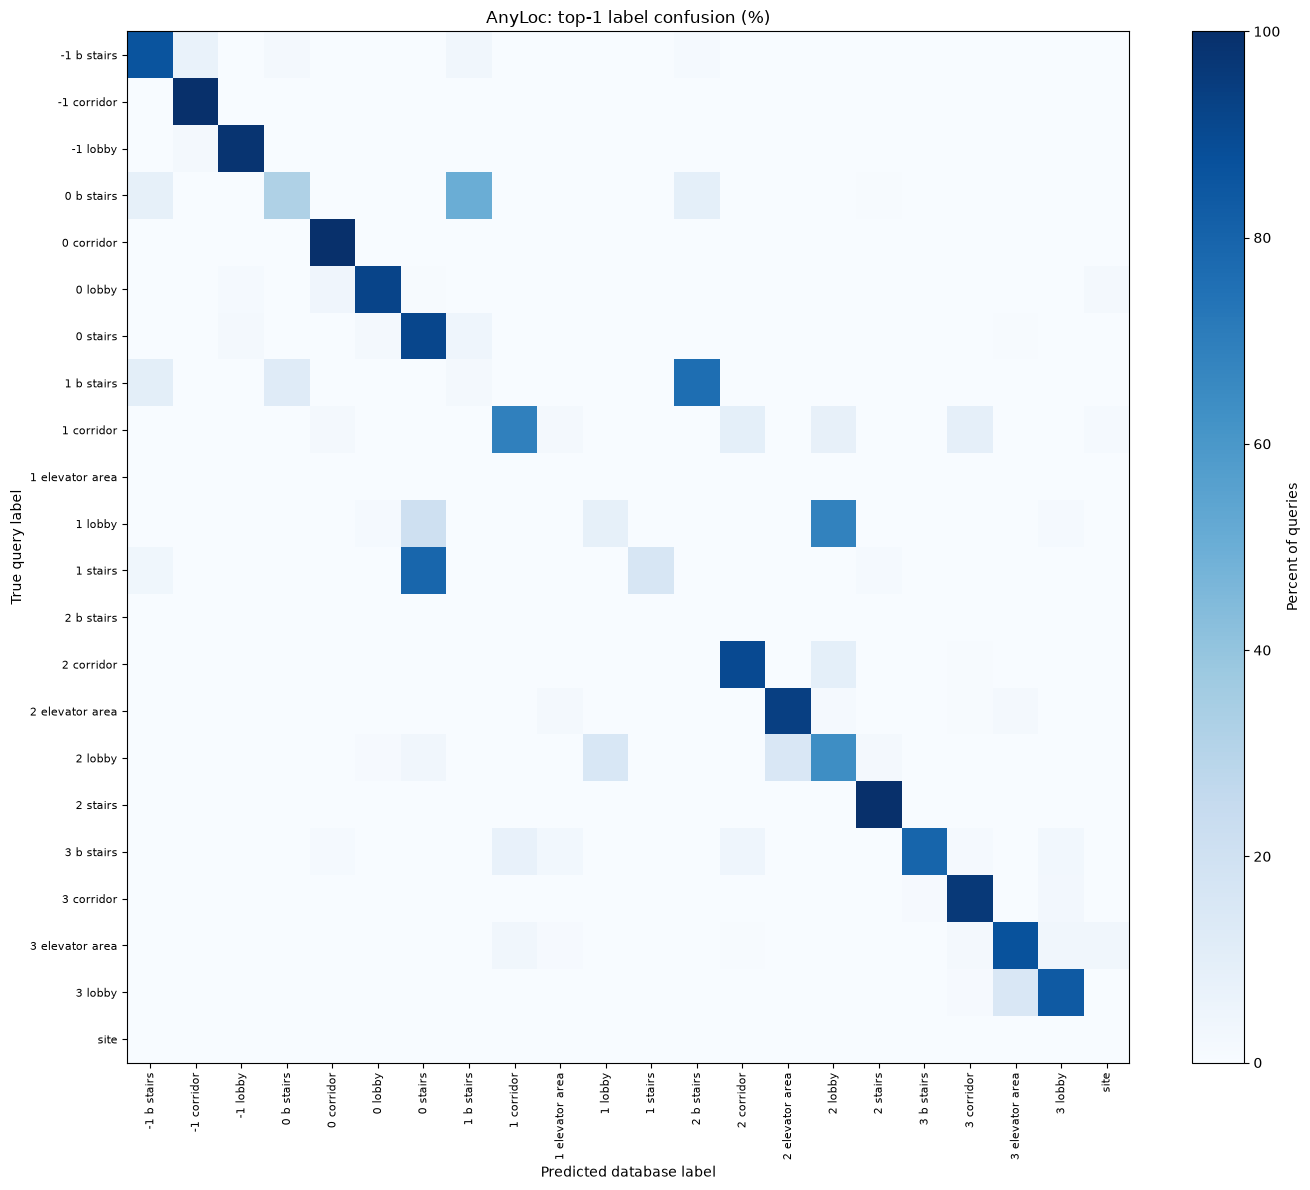


MODEL: CosPlace (ResNet50, 2048-D)
Top-1 confusion matrix; rows=true labels, columns=predicted labels; values=row-normalized percentages.
true_label	-1 b stairs	-1 corridor	-1 lobby	0 b stairs	0 corridor	0 lobby	0 stairs	1 b stairs	1 corridor	1 elevator area	1 lobby	1 stairs	2 b stairs	2 corridor	2 elevator area	2 lobby	2 stairs	3 b stairs	3 corridor	3 elevator area	3 lobby	site
-1 b stairs	64.19	8.73	0.00	3.93	0.87	13.97	0.00	1.31	0.00	1.31	0.00	0.00	4.80	0.00	0.00	0.00	0.00	0.00	0.00	0.87	0.00	0.00
-1 corridor	0.00	97.65	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.70	0.23	0.00	0.00	0.00	0.94	0.23	0.23	0.00
-1 lobby	0.00	4.50	88.29	0.00	0.00	0.90	0.00	0.00	0.00	0.90	0.00	0.00	0.00	1.80	0.00	2.70	0.90	0.00	0.00	0.00	0.00	0.00
0 b stairs	6.06	0.00	0.00	29.00	0.00	0.43	0.00	41.56	0.00	0.00	0.00	0.00	22.94	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00
0 corridor	2.21	0.00	0.00	0.00	87.29	7.18	0.00	0.00	0.00	0.55	0.00	0.00	0.00	2.21	0.00	0.00	0.00	0.00	0.00	0.55	0.00	0.00
0 lo

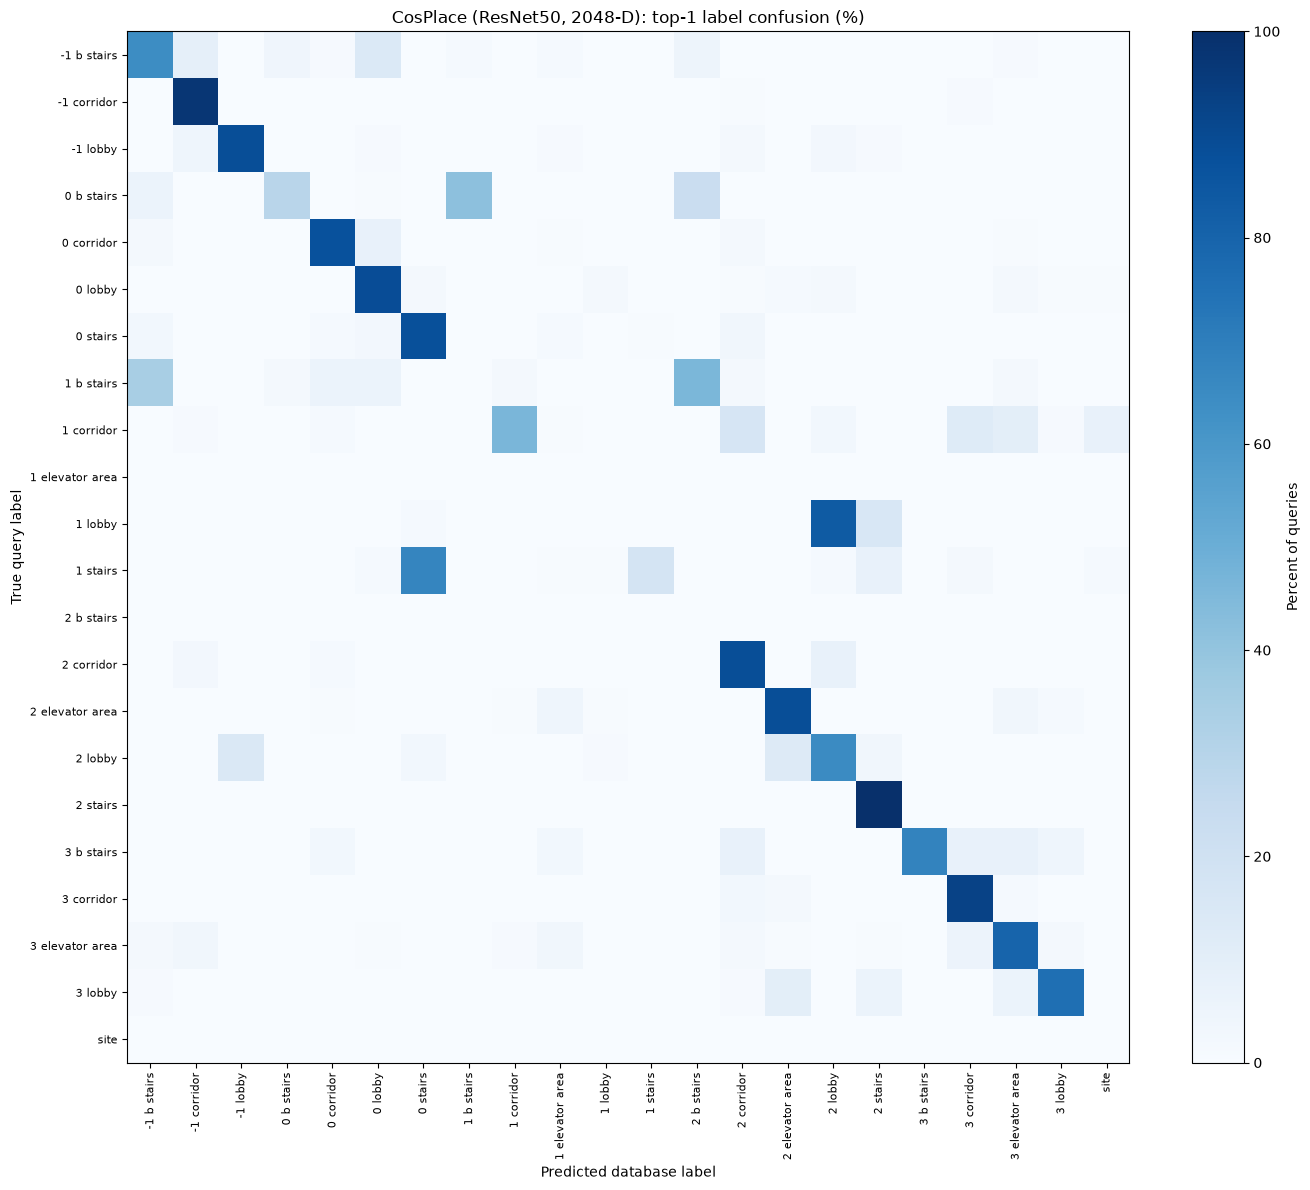


MODEL: MixVPR
Top-1 confusion matrix; rows=true labels, columns=predicted labels; values=row-normalized percentages.
true_label	-1 b stairs	-1 corridor	-1 lobby	0 b stairs	0 corridor	0 lobby	0 stairs	1 b stairs	1 corridor	1 elevator area	1 lobby	1 stairs	2 b stairs	2 corridor	2 elevator area	2 lobby	2 stairs	3 b stairs	3 corridor	3 elevator area	3 lobby	site
-1 b stairs	85.15	6.55	0.00	2.18	0.00	1.31	0.44	0.44	0.00	1.75	0.00	0.00	2.18	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00
-1 corridor	0.00	99.53	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.47	0.00	0.00
-1 lobby	0.00	3.60	96.40	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00
0 b stairs	7.36	0.00	0.00	37.23	0.00	0.00	0.00	40.26	0.00	0.00	0.00	0.00	15.15	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00
0 corridor	0.00	0.00	0.00	0.00	97.24	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	2.76	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00
0 lobby	0.00	0.00	0.00	0.0

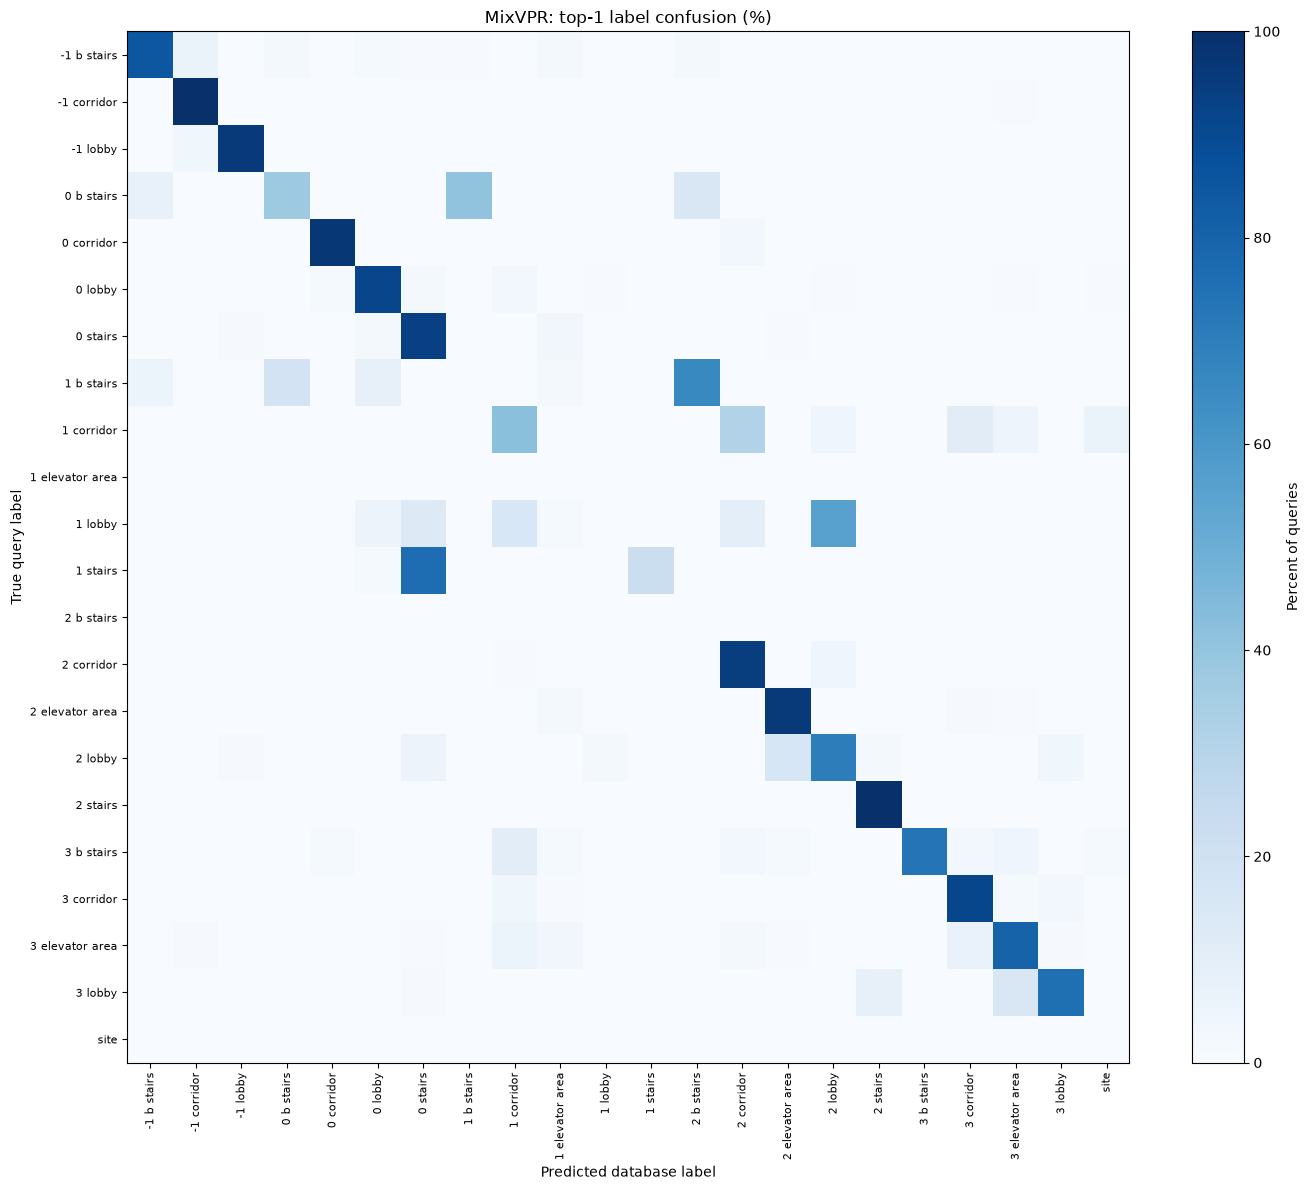


MODEL: NetVLAD (ResNet101-conv4, Pitts30k)
Top-1 confusion matrix; rows=true labels, columns=predicted labels; values=row-normalized percentages.
true_label	-1 b stairs	-1 corridor	-1 lobby	0 b stairs	0 corridor	0 lobby	0 stairs	1 b stairs	1 corridor	1 elevator area	1 lobby	1 stairs	2 b stairs	2 corridor	2 elevator area	2 lobby	2 stairs	3 b stairs	3 corridor	3 elevator area	3 lobby	site
-1 b stairs	79.48	6.11	0.00	2.62	0.00	3.93	0.00	0.00	0.00	0.00	0.00	0.00	7.86	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00
-1 corridor	0.00	98.83	0.00	0.00	0.00	0.23	0.00	0.00	0.00	0.47	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.23	0.00	0.23
-1 lobby	0.00	6.31	91.89	0.00	0.00	1.80	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00
0 b stairs	4.33	0.00	0.00	27.71	0.00	0.00	0.00	42.86	0.00	0.00	0.00	0.00	24.68	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.43	0.00
0 corridor	0.00	0.00	0.00	0.00	98.34	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.00	1.66	0.00	0.00	0.00	0.00	0.00	0.00	0.00	0.

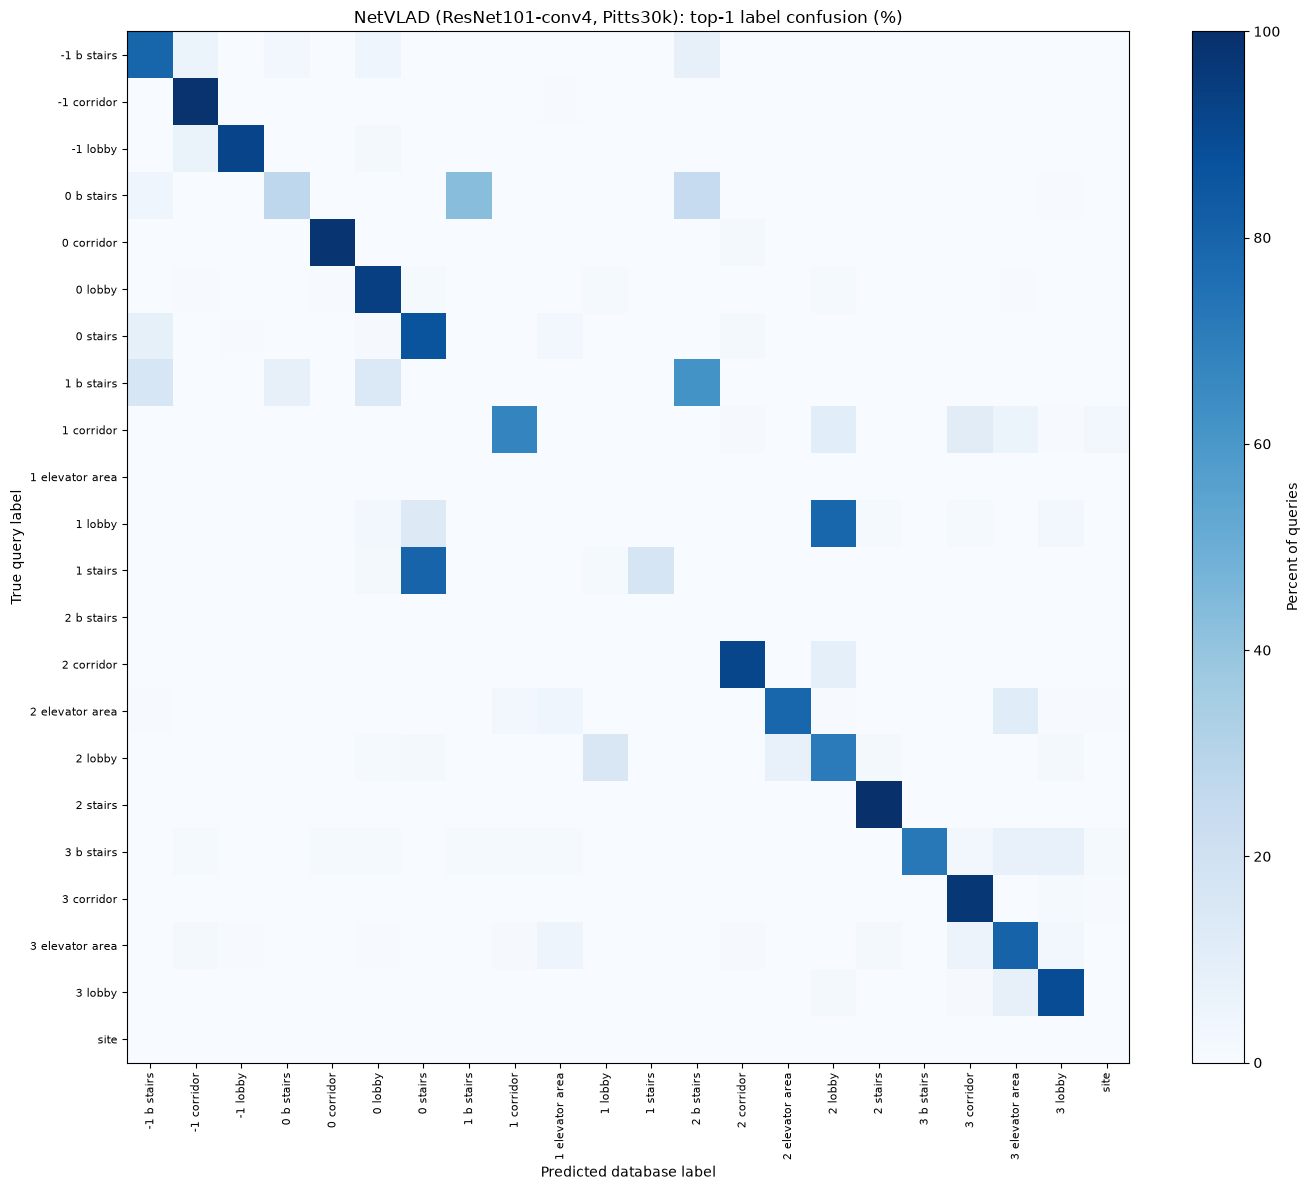

In [18]:
matrix_labels = sorted(
    {row['true_label'] for row in all_confusion_rows}
    | {row['predicted_label'] for row in all_confusion_rows}
)
label_index = {label: index for index, label in enumerate(matrix_labels)}

for model in models:
    matrix = np.zeros((len(matrix_labels), len(matrix_labels)), dtype=np.float64)
    for row in all_confusion_rows:
        if row['model'] == model:
            matrix[label_index[row['true_label']], label_index[row['predicted_label']]] += row['count']
    row_totals = matrix.sum(axis=1, keepdims=True)
    normalized = np.divide(matrix, row_totals, out=np.zeros_like(matrix), where=row_totals > 0) * 100
    safe_model = ''.join(character.lower() if character.isalnum() else '_' for character in model).strip('_')
    matrix_lines = [
        f'MODEL: {model}',
        'Top-1 confusion matrix; rows=true labels, columns=predicted labels; values=row-normalized percentages.',
        'true_label\t' + '\t'.join(matrix_labels),
    ]
    for label, values in zip(matrix_labels, normalized):
        matrix_lines.append(label + '\t' + '\t'.join(f'{value:.2f}' for value in values))
    model_confusions = [row for row in confusion_table_rows if row['model'] == model]
    matrix_lines.extend(['', 'TOP WRONG PREDICTIONS PER TRUE LABEL', markdown_table(
        model_confusions, confusion_columns,
        percent_columns={'all_query_rate', 'share_of_errors'},
    )])
    confusion_text = '\n'.join(matrix_lines)
    confusion_path = CONFUSION_TEXT_DIR / f'{safe_model}_top1_confusion.txt'
    confusion_path.write_text(confusion_text + '\n', encoding='utf-8')
    print('\n' + '=' * 80 + '\n' + confusion_text)
    print(f'\nSaved confusion text to {confusion_path}')

    figure, axis = plt.subplots(figsize=(14, 12))
    image = axis.imshow(normalized, cmap='Blues', vmin=0, vmax=100, aspect='auto')
    axis.set_title(f'{model}: top-1 label confusion (%)')
    axis.set_xlabel('Predicted database label')
    axis.set_ylabel('True query label')
    axis.set_xticks(range(len(matrix_labels)), matrix_labels, rotation=90, fontsize=8)
    axis.set_yticks(range(len(matrix_labels)), matrix_labels, fontsize=8)
    figure.colorbar(image, ax=axis, label='Percent of queries')
    figure.tight_layout()
    figure.savefig(FIGURE_DIR / f'{safe_model}_top1_confusion_matrix.pdf', bbox_inches='tight')
    figure.savefig(FIGURE_DIR / f'{safe_model}_top1_confusion_matrix.png', bbox_inches='tight', dpi=300)
    plt.show()